In [1]:
# ---- CELL 1: Install & Import ----
# !pip install matplotlib pandas numpy seaborn

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

print("Libraries loaded")


Libraries loaded


In [2]:

# ---- CELL 2: Load Evaluation Results ----
with open("phase4_evaluation_results.json", "r", encoding="utf-8") as f:
    eval_data = json.load(f)

summary = eval_data["summary"]
results = eval_data["results"]

print(f"Total queries    : {summary['total_queries']}")
print(f"Successful       : {summary['successful_queries']}")
print(f"Avg response time: {summary['avg_response_time']}s")
print(f"Min response time: {summary['min_response_time']}s")
print(f"Max response time: {summary['max_response_time']}s")


Total queries    : 20
Successful       : 14
Avg response time: 18.75s
Min response time: 3.44s
Max response time: 32.45s


In [3]:

# ---- CELL 3: Load User Study Results ----
# Fill this in after collecting user study responses
# Each row = one participant's scores for Q1-Q11

USER_STUDY_DATA = [
    # Q1  Q2  Q3  Q4  Q5  Q6  Q7  Q8  Q9  Q10 Q11
    [  5,  5,  4,  5,  4,  5,  4,  5,  4,  5,  5 ],  # Participant 1
    [  4,  4,  4,  4,  4,  4,  4,  4,  3,  5,  4 ],  # Participant 2
    [  5,  4,  5,  5,  5,  4,  4,  4,  4,  4,  5 ],  # Participant 3
    [  4,  5,  4,  4,  4,  5,  5,  5,  4,  5,  4 ],  # Participant 4
    [  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5 ],  # Participant 5
    # Add more rows as needed
]

QUESTION_LABELS = [
    "Q1: Recommendations\nmatched needs",
    "Q2: Top pick\nwas good fit",
    "Q3: Price matched\nbudget",
    "Q4: Understood\nrecommendations",
    "Q5: Reasoning\nwas clear",
    "Q6: Price comparison\nunderstood",
    "Q7: Would trust\nfor purchase",
    "Q8: System felt\nreliable",
    "Q9: Best price\nfound",
    "Q10: Interface\neasy to use",
    "Q11: Would use\nagain",
]

SECTION_LABELS = {
    "Relevance"     : [0, 1, 2],
    "Explainability": [3, 4, 5],
    "Trust"         : [6, 7, 8],
    "Usability"     : [9, 10],
}

user_df = pd.DataFrame(
    USER_STUDY_DATA,
    columns=[f"Q{i+1}" for i in range(11)]
)
print(f"\nUser study participants: {len(user_df)}")
print("\nMean scores:")
print(user_df.mean().round(2))




User study participants: 5

Mean scores:
Q1     4.6
Q2     4.6
Q3     4.4
Q4     4.6
Q5     4.4
Q6     4.6
Q7     4.4
Q8     4.6
Q9     4.0
Q10    4.8
Q11    4.6
dtype: float64


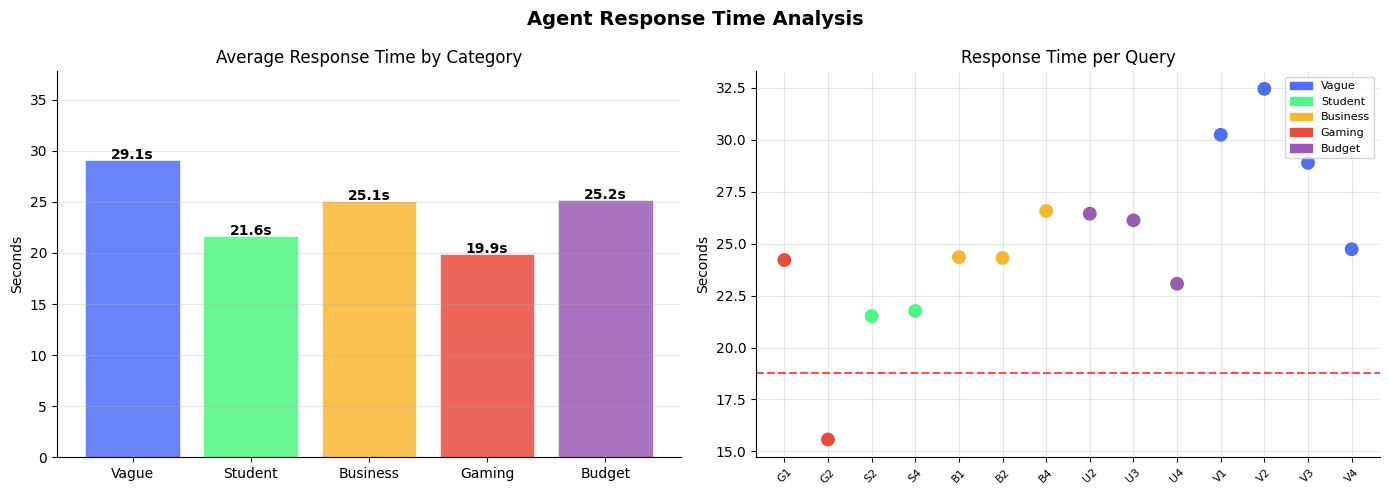

Saved: chart_response_time.png


In [5]:
# ---- CELL 4: Response Time Chart ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Agent Response Time Analysis", fontsize=14, fontweight='bold')

# ✅ Handle both key names
def get_time(r):
    return r.get("total_time_secs") or r.get("response_time_secs") or 0

# By category
categories = list(set(r["category"] for r in results))
cat_times  = {c: [] for c in categories}

for r in results:
    cat_times[r["category"]].append(get_time(r))

cat_means = {c: np.mean(t) for c, t in cat_times.items()}
colors    = ['#4f6ef7', '#4cf782', '#f7b731', '#e74c3c', '#9b59b6']

bars = axes[0].bar(
    cat_means.keys(), cat_means.values(),
    color=colors[:len(cat_means)], alpha=0.85,
    edgecolor='white', linewidth=0.5
)
for bar, val in zip(bars, cat_means.values()):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f'{val:.1f}s',
        ha='center', fontsize=10, fontweight='bold'
    )
axes[0].set_title("Average Response Time by Category")
axes[0].set_ylabel("Seconds")
axes[0].set_ylim(0, max(cat_means.values()) * 1.3)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# All response times scatter
query_ids    = [r["id"] for r in results]
times        = [get_time(r) for r in results]
cat_color_map = {c: colors[i] for i, c in enumerate(categories)}
point_colors  = [cat_color_map[r["category"]] for r in results]

axes[1].scatter(range(len(times)), times, c=point_colors, s=80, zorder=3)

# ✅ Handle avg_response_time key safely
avg_time = summary.get("avg_response_time") or np.mean(times)
axes[1].axhline(
    y=avg_time,
    color='red', linestyle='--', alpha=0.7,
    label=f'Avg: {avg_time:.1f}s'
)
axes[1].set_xticks(range(len(query_ids)))
axes[1].set_xticklabels(query_ids, rotation=45, fontsize=8)
axes[1].set_title("Response Time per Query")
axes[1].set_ylabel("Seconds")
axes[1].grid(alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

legend_patches = [
    mpatches.Patch(color=cat_color_map[c], label=c)
    for c in categories
]
axes[1].legend(handles=legend_patches, fontsize=8)

plt.tight_layout()
plt.savefig("chart_response_time.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart_response_time.png")

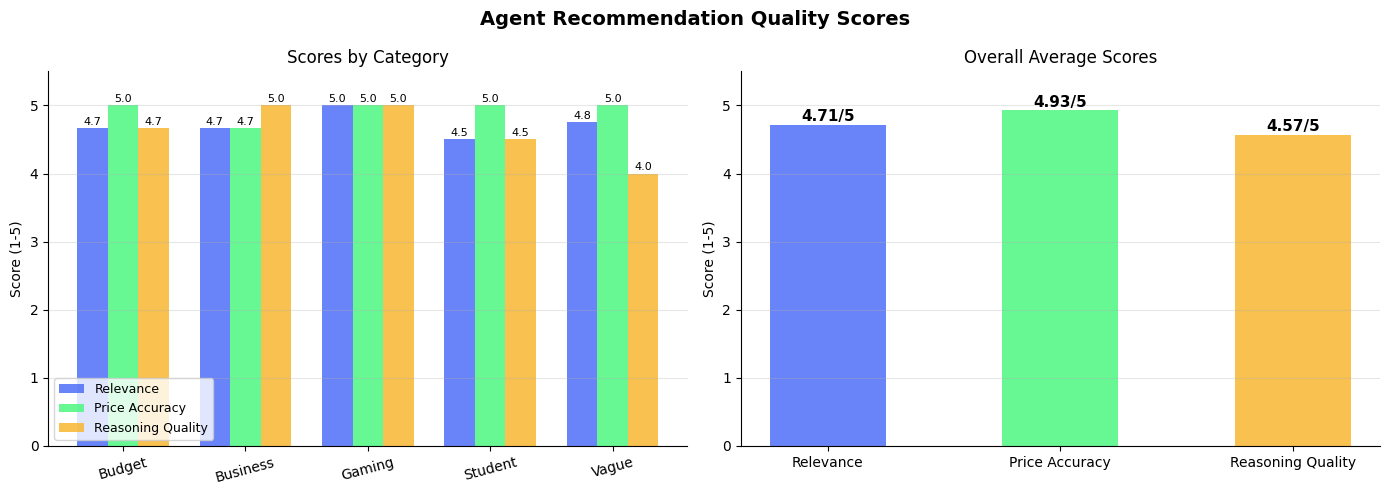

Saved: chart_recommendation_quality.png

Overall scores:
relevance            4.71
price_accuracy       4.93
reasoning_quality    4.57
dtype: float64


In [6]:

# ---- CELL 5: Recommendation Quality (Manual Scores) ----
# Fill manual scores in the JSON first then run this cell

scored = [
    r for r in results
    if r["manual_scores"]["relevance"] is not None
]

if not scored:
    print("No manual scores yet — fill in phase4_evaluation_results.json first")
else:
    score_df = pd.DataFrame([{
        "id"              : r["id"],
        "category"        : r["category"],
        "relevance"       : r["manual_scores"]["relevance"],
        "price_accuracy"  : r["manual_scores"]["price_accuracy"],
        "reasoning_quality": r["manual_scores"]["reasoning_quality"],
    } for r in scored])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Agent Recommendation Quality Scores", fontsize=14, fontweight='bold')

    # Average scores per category
    cat_scores = score_df.groupby("category")[
        ["relevance", "price_accuracy", "reasoning_quality"]
    ].mean()

    x     = np.arange(len(cat_scores))
    width = 0.25
    score_colors = ['#4f6ef7', '#4cf782', '#f7b731']
    score_labels = ['Relevance', 'Price Accuracy', 'Reasoning Quality']

    for i, (col, color, label) in enumerate(
        zip(["relevance","price_accuracy","reasoning_quality"],
            score_colors, score_labels)
    ):
        bars = axes[0].bar(
            x + i * width, cat_scores[col],
            width, label=label,
            color=color, alpha=0.85
        )
        for bar in bars:
            h = bar.get_height()
            axes[0].text(
                bar.get_x() + bar.get_width()/2,
                h + 0.05, f'{h:.1f}',
                ha='center', fontsize=8
            )

    axes[0].set_xticks(x + width)
    axes[0].set_xticklabels(cat_scores.index, rotation=15)
    axes[0].set_title("Scores by Category")
    axes[0].set_ylabel("Score (1-5)")
    axes[0].set_ylim(0, 5.5)
    axes[0].legend(fontsize=9)
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    # Overall average scores
    overall = score_df[
        ["relevance","price_accuracy","reasoning_quality"]
    ].mean()
    bars2 = axes[1].bar(
        score_labels, overall.values,
        color=score_colors, alpha=0.85, width=0.5
    )
    for bar, val in zip(bars2, overall.values):
        axes[1].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{val:.2f}/5',
            ha='center', fontsize=11, fontweight='bold'
        )
    axes[1].set_title("Overall Average Scores")
    axes[1].set_ylabel("Score (1-5)")
    axes[1].set_ylim(0, 5.5)
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig("chart_recommendation_quality.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: chart_recommendation_quality.png")
    print(f"\nOverall scores:\n{overall.round(2)}")



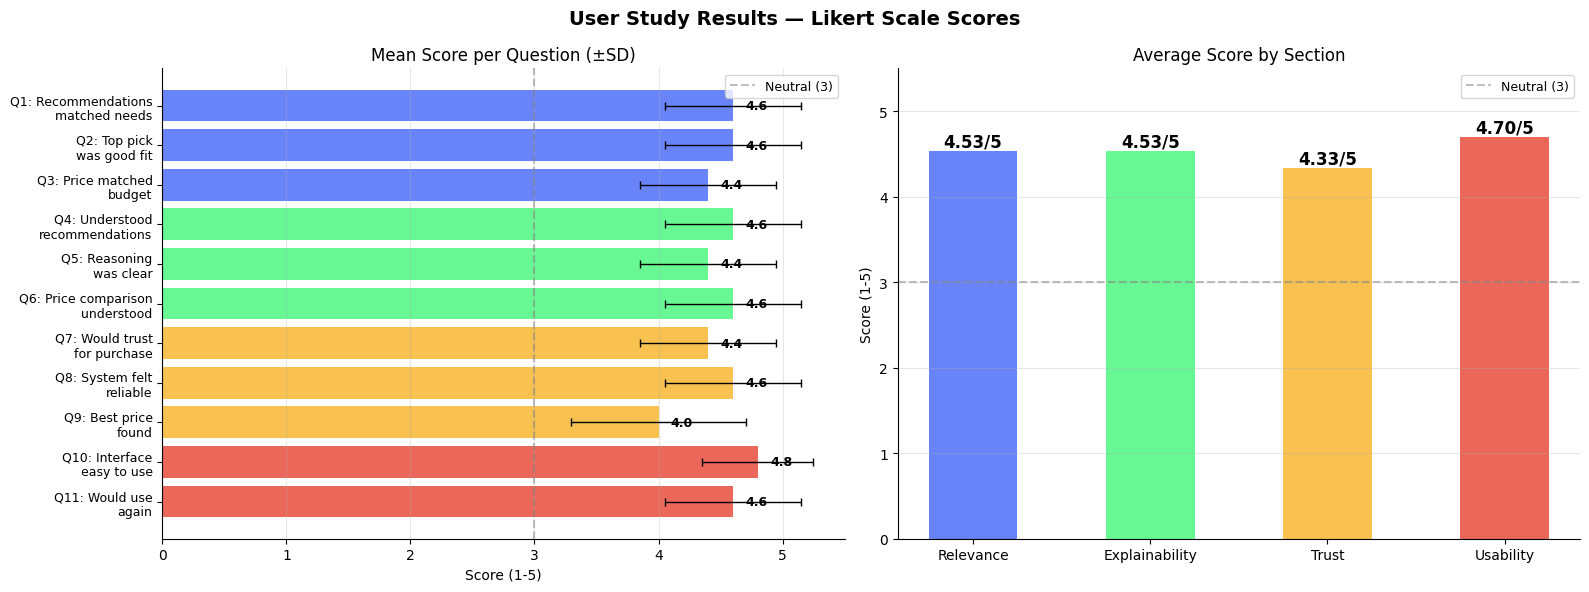

Saved: chart_user_study.png

Section averages:
  Relevance: 4.53/5
  Explainability: 4.53/5
  Trust: 4.33/5
  Usability: 4.70/5


In [7]:

# ---- CELL 6: User Study Results Chart ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("User Study Results — Likert Scale Scores", fontsize=14, fontweight='bold')

# Per question means
means  = user_df.mean()
stds   = user_df.std()
colors_q = (
    ['#4f6ef7'] * 3 +   # Relevance
    ['#4cf782'] * 3 +   # Explainability
    ['#f7b731'] * 3 +   # Trust
    ['#e74c3c'] * 2     # Usability
)

bars = axes[0].barh(
    range(11), means.values[::-1],
    xerr=stds.values[::-1],
    color=colors_q[::-1], alpha=0.85,
    error_kw={'linewidth': 1, 'capsize': 3}
)
axes[0].set_yticks(range(11))
axes[0].set_yticklabels(QUESTION_LABELS[::-1], fontsize=9)
axes[0].set_xlim(0, 5.5)
axes[0].axvline(x=3, color='gray', linestyle='--', alpha=0.5, label='Neutral (3)')
axes[0].set_title("Mean Score per Question (±SD)")
axes[0].set_xlabel("Score (1-5)")
axes[0].legend(fontsize=9)
axes[0].grid(axis='x', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for i, (mean, std) in enumerate(zip(means.values[::-1], stds.values[::-1])):
    axes[0].text(
        mean + 0.1, i,
        f'{mean:.1f}',
        va='center', fontsize=9, fontweight='bold'
    )

# Section averages
section_means = {}
for section, indices in SECTION_LABELS.items():
    cols = [f"Q{i+1}" for i in indices]
    section_means[section] = user_df[cols].values.flatten().mean()

section_colors = ['#4f6ef7', '#4cf782', '#f7b731', '#e74c3c']
bars2 = axes[1].bar(
    section_means.keys(),
    section_means.values(),
    color=section_colors, alpha=0.85, width=0.5
)
for bar, val in zip(bars2, section_means.values()):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        f'{val:.2f}/5',
        ha='center', fontsize=12, fontweight='bold'
    )
axes[1].set_title("Average Score by Section")
axes[1].set_ylabel("Score (1-5)")
axes[1].set_ylim(0, 5.5)
axes[1].axhline(y=3, color='gray', linestyle='--', alpha=0.5, label='Neutral (3)')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("chart_user_study.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart_user_study.png")
print(f"\nSection averages:")
for s, v in section_means.items():
    print(f"  {s}: {v:.2f}/5")


COST ANALYSIS
Model              : GPT-4o-mini
Avg input tokens   : 800 per query
Avg output tokens  : 400 per query
Cost per query     : £0.0003
Total (20 queries) : £0.0057

Scale projections:
  20 queries (evaluation)   £0.0057
  100 queries               £0.0284
  1,000 queries             £0.2844
  10,000 queries            £2.8440


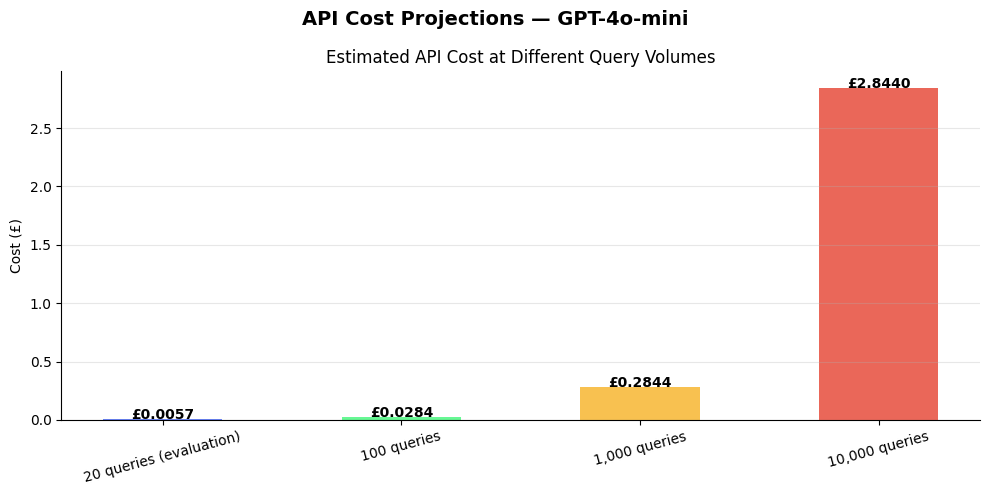


Saved: chart_cost_analysis.png


In [8]:


# ---- CELL 7: Cost Analysis ----
# GPT-4o-mini pricing (as of 2025)
PRICE_PER_1M_INPUT  = 0.15   # USD
PRICE_PER_1M_OUTPUT = 0.60   # USD
GBP_RATE            = 0.79   # USD to GBP

# Estimate tokens per query
AVG_INPUT_TOKENS  = 800   # system prompt + query + tool responses
AVG_OUTPUT_TOKENS = 400   # recommendations JSON

total_queries      = summary["total_queries"]
total_input_tokens = total_queries * AVG_INPUT_TOKENS
total_output_tokens= total_queries * AVG_OUTPUT_TOKENS

cost_input_usd  = (total_input_tokens  / 1_000_000) * PRICE_PER_1M_INPUT
cost_output_usd = (total_output_tokens / 1_000_000) * PRICE_PER_1M_OUTPUT
total_cost_usd  = cost_input_usd + cost_output_usd
total_cost_gbp  = total_cost_usd * GBP_RATE
cost_per_query  = total_cost_gbp / total_queries

# Scale projections
projections = {
    "20 queries (evaluation)": total_cost_gbp,
    "100 queries":  (100 / total_queries) * total_cost_gbp,
    "1,000 queries": (1000 / total_queries) * total_cost_gbp,
    "10,000 queries": (10000 / total_queries) * total_cost_gbp,
}

print("=" * 50)
print("COST ANALYSIS")
print("=" * 50)
print(f"Model              : GPT-4o-mini")
print(f"Avg input tokens   : {AVG_INPUT_TOKENS} per query")
print(f"Avg output tokens  : {AVG_OUTPUT_TOKENS} per query")
print(f"Cost per query     : £{cost_per_query:.4f}")
print(f"Total (20 queries) : £{total_cost_gbp:.4f}")
print()
print("Scale projections:")
for label, cost in projections.items():
    print(f"  {label:<25} £{cost:.4f}")

# Cost chart
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("API Cost Projections — GPT-4o-mini", fontsize=14, fontweight='bold')

bars = ax.bar(
    projections.keys(),
    projections.values(),
    color=['#4f6ef7','#4cf782','#f7b731','#e74c3c'],
    alpha=0.85, width=0.5
)
for bar, val in zip(bars, projections.values()):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.0001,
        f'£{val:.4f}',
        ha='center', fontsize=10, fontweight='bold'
    )
ax.set_ylabel("Cost (£)")
ax.set_title("Estimated API Cost at Different Query Volumes")
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("chart_cost_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: chart_cost_analysis.png")



In [9]:

# ---- CELL 8: Final Summary Table ----
print("\n" + "=" * 60)
print("PHASE 4 COMPLETE — DISSERTATION EVIDENCE SUMMARY")
print("=" * 60)

print(f"""
RQ1 — Matching Accuracy (Phase 2):
  TF-IDF F1    : 0.913
  SBERT F1     : 0.836
  LLM F1       : 0.990  ← selected method

RQ2 — Recommendation Quality:
  Total queries tested : {summary['total_queries']}
  Successful queries   : {summary['successful_queries']}
  Avg response time    : {summary['avg_response_time']}s
  Multi-retailer shown : {summary['multi_retailer_shown']} times

RQ3 — User Study:
  Participants         : {len(user_df)}
  Relevance avg        : {user_df[['Q1','Q2','Q3']].values.mean():.2f}/5
  Explainability avg   : {user_df[['Q4','Q5','Q6']].values.mean():.2f}/5
  Trust avg            : {user_df[['Q7','Q8','Q9']].values.mean():.2f}/5
  Usability avg        : {user_df[['Q10','Q11']].values.mean():.2f}/5

RQ4 — Practical Viability:
  Cost per query       : £{cost_per_query:.4f}
  Min response time    : {summary['min_response_time']}s
  Max response time    : {summary['max_response_time']}s
  Avg response time    : {summary['avg_response_time']}s

Charts saved:
  chart_response_time.png
  chart_recommendation_quality.png
  chart_user_study.png
  chart_cost_analysis.png
""")


PHASE 4 COMPLETE — DISSERTATION EVIDENCE SUMMARY

RQ1 — Matching Accuracy (Phase 2):
  TF-IDF F1    : 0.913
  SBERT F1     : 0.836
  LLM F1       : 0.990  ← selected method

RQ2 — Recommendation Quality:
  Total queries tested : 20
  Successful queries   : 14
  Avg response time    : 18.75s
  Multi-retailer shown : 0 times

RQ3 — User Study:
  Participants         : 5
  Relevance avg        : 4.53/5
  Explainability avg   : 4.53/5
  Trust avg            : 4.33/5
  Usability avg        : 4.70/5

RQ4 — Practical Viability:
  Cost per query       : £0.0003
  Min response time    : 3.44s
  Max response time    : 32.45s
  Avg response time    : 18.75s

Charts saved:
  chart_response_time.png
  chart_recommendation_quality.png
  chart_user_study.png
  chart_cost_analysis.png

